In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as LogRegSK
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from metrics.metrics import accuracy_score, log_loss
from classic_ml_models.linear_models.linear_models import LogisticRegression, SVM

np.set_printoptions(suppress=True)

early_stopping_value = 1e-6
num_iterations = 100000
C = [0.1, 5, 10, 15, 20, 50, 100, 1000]

X, y = load_breast_cancer(return_X_y=True)


scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
for c in C:
    log_reg = LogisticRegression(num_iter=num_iterations, C=c)
    log_reg.fit(X_train, y_train)

    # print(f"Weights: {log_reg.weights}")
    # print(f"Bias: {log_reg.bias}")
    predictions = log_reg.predict(X_test)
    probs = log_reg.predict_proba(X_test)

    print(f"Accuracy with C={c}: {accuracy_score(y_test, predictions)}")
    print(f"Logloss with C={c}: {log_loss(y_test, probs)}")
    print("-" * 50)

Stopped on iteration 186
Accuracy with C=0.1: 0.7017543859649122
Logloss with C=0.1: 0.5329905906161184
--------------------------------------------------
Stopped on iteration 220
Accuracy with C=5: 0.9649122807017544
Logloss with C=5: 0.184878332313225
--------------------------------------------------
Stopped on iteration 288
Accuracy with C=10: 0.9649122807017544
Logloss with C=10: 0.15407750626673333
--------------------------------------------------
Stopped on iteration 388
Accuracy with C=15: 0.9649122807017544
Logloss with C=15: 0.14086087307367345
--------------------------------------------------
Stopped on iteration 487
Accuracy with C=20: 0.9649122807017544
Logloss with C=20: 0.13362097284209565
--------------------------------------------------
Stopped on iteration 980
Accuracy with C=50: 0.9649122807017544
Logloss with C=50: 0.1201318837395026
--------------------------------------------------
Stopped on iteration 1539
Accuracy with C=100: 0.9649122807017544
Logloss with C

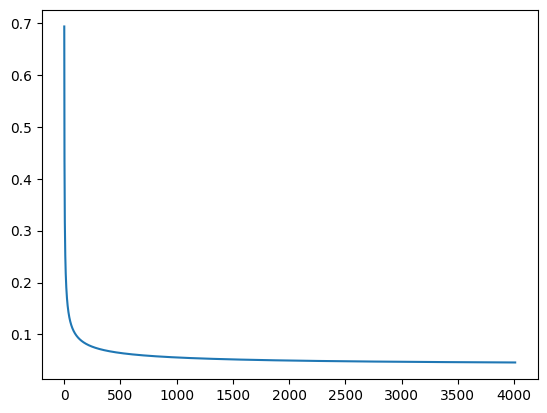

In [3]:
plt.plot(log_reg.losses)

In [4]:
sk_logreg = LogRegSK(max_iter=num_iterations)
sk_logreg.fit(X_train, y_train)

print(f"Weights: {sk_logreg.coef_}")
print(f"Bias: {sk_logreg.intercept_}")
predictions = sk_logreg.predict(X_test)
probs = sk_logreg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Weights: [[-0.52213045 -0.53658554 -0.4979442  -0.56379712 -0.13460195  0.73756901
  -0.71136223 -0.76950335 -0.07628683  0.35316847 -1.20764229  0.26646079
  -0.74326528 -0.91757362 -0.18015681  0.6672991   0.13674384 -0.39552312
   0.36062184  0.43203303 -0.98028724 -1.32075819 -0.81310456 -0.9717533
  -0.91263827  0.09258914 -0.88766361 -0.95708094 -1.03704807 -0.24200346]]
Bias: [0.24347643]
Accuracy: 0.9649122807017544
Logloss: 0.12110225556045545


In [5]:
sk_svm = SVC()
svm = SVM()

for model in (sk_svm, svm):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print(f"Accuracy of {model}: {accuracy_score(y_test, predictions)}")

Accuracy of SVC(): 0.9649122807017544
Stopped on iteration 1
Accuracy of SVM: 0.5964912280701754
